<h1><center>Laboratorio 8: Predicciones y Recomendaciones 🔮🪄 </center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2024</strong></center>

### **Cuerpo Docente:**

- Profesores: Ignacio Meza, Sebastián Tinoco
- Auxiliar: Eduardo Moya
- Ayudantes: Nicolás Ojeda, Melanie Peña, Valentina Rojas

### **Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados**

- Nombre de alumno 1: Angelo León
- Nombre de alumno 2: Damián De Aguiar

### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/damiatus/labPrograCientifica)

## Temas a tratar
- Series de Tiempo.
- Predicciones vía `Prophet`.
- Implementar un sistema de recomendación utilizando `surprise`.

## Reglas:

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias.
- Pueden usar cualquer matrial del curso que estimen conveniente.
- Código que no se pueda ejecutar, no será revisado.

### Objetivos principales del laboratorio
- Comprender qué es una serie de tiempo y su estructura.
- Identificar tendencias, estacionalidades e irregularidades.
- Armar un modelo predictivo para la serie.
- Conocer y aplicar sistemas de recomendación.
- Entender estructura y conocer casos de estudio.


In [62]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    path = '/content/drive/MyDrive/LabdeProgra/Lab 8 - Forecasting y sistema de recomendación'
except:
    print('Ignorando conexión drive-colab')

Ignorando conexión drive-colab


In [68]:
# Librerias globales

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import plotly.express as px

# **1. Forecasting (30 puntos)**


## **Prophet**

Prophet es una herramienta open-source de Facebook utilizada para realizar predicciones en series de tiempo. Esta se basa en la descomposición aditiva, donde tendencias no lineales se ajustan junto a la estacionalidad.

En la ecuación de a continuación se puede ver una idea general de los elementos que construyen a un modelo aditivo como lo es Prophet.

\begin{equation}
y(t) = g(t) + s(t) + h(t) + e(t)
\end{equation}

Donde, $g(t)$ hace referencia a las tendencias, que corresponden a cambios graduales en largos periodos de tiempo. $s(t)$ corresponde a la estacionalidad, son cambios periodicos o cortos en el tiempo. $h(t)$ es el efecto que tienen las festividades sobre las predicciones, mientras que e(t) corresponde al error o ruido. Finalmente $y(t)$, es la predicción hecha por el modelo.

Prophet trabaja por defecto con Piece-Wise Lineal Model, este es un modelo de regresión lineal, en el cual se buscan distintas zonas en que la data presente patrones o tendencias lineales, de estas zonas obtiene su regresión y luego las "une" de manera de representar toda la región, como se puede ver en la ecuación siguiente.

\begin{equation}
y(x)=
    \begin{cases}
        η_1 + \beta_1(x-b_1), & b_1 < x  \leqslant b_2 \\
        η_2 + \beta_2(x-b_2), & b_2 < x  \leqslant b_3 \\
        η_3 + \beta_3(x-b_3), & b_3 < x  \leqslant b_3 \\
        ... \\
        η_k + \beta_{nb}(x-b_{nb-1}), & b_{n-1} < x  \leqslant b_{nb} \\
    \end{cases}
\end{equation}

Siendo $b_1$ el primer punto de quiebre en la serie y así hasta el punto $b_{nb}$ correspondiente al último punto de quiebre de la serie con una cantidad $nb$ de puntos.

Para mayor información de Prophet y como utilizarla, pueden ver su [documentación](https://facebook.github.io/prophet/docs/quick_start.html#python-api), donde hay pueden encontrar un pequeño tutorial de la librería.

## **La Factura de Homero**

<center>
<img src ="https://i.makeagif.com/media/7-30-2018/H_ZAY1.gif" width = 500 />

Homero Simpson ha trabajado en la Planta Nuclear de Springfield por más de 20 años como Inspector de Seguridad, pero recientemente el Sr. Burns le ha permitido trabajar desde casa. Aunque le encanta la flexibilidad que esto le otorga, también ha notado un aumento considerable en su consumo energético en el hogar. Con el uso constante de calefacción en invierno y aire acondicionado en verano, Homero está preocupado por cómo afectará esto a su presupuesto en los próximos meses, ya que planea pasar aún más tiempo en casa.

Afortunadamente, gracias a su puesto en la Planta de Energía Nuclear, Homero tiene acceso a los datos de consumo de energía de cada ciudadano en Springfield, por lo que accede a esta información y almacena el consumo de su hogar en un archivo llamado `energia_homero.csv`. Este archivo posee el consumo diario en el hogar de Homero Simpson desde el Junio del 2016 hasta Julio del 2020.

Con esta valiosa información, Homero espera poder predecir su consumo energético y tomar decisiones informadas para ajustar su presupuesto mensual.

Los datos son los siguientes:

* **date**: Fecha de medición.
* **Energy_kWh**: Consumo diario de energía eléctrica en el hogar de Homero (en kWh).

## 1.1 Series de Tiempo [0 puntos]

### Carga de los datos

En primer lugar, cargue los datos históricos del archivo `energia_homero.csv` al entorno de trabajo. Una vez cargados, asegúrense de transformar la columna `date` a formato `datetime`. Además, visualice el consumo de energía en la casa de Homero mediante la librería `plotly`.


**Respuesta**:

In [98]:
# energia_homero = pd.read_csv(path + "/energia_homero.csv")
energia_homero = pd.read_csv('./energia_homero.csv')

energia_homero['date'] = pd.to_datetime(energia_homero['date'])

fig = px.line(energia_homero, x='date', y='Energy_kWh', title='Consumo de Energía Casa Homero')
fig.show()

## 1.2 Controlando la Serie de Tiempo [6 puntos]

<center>
<img src ="https://i.pinimg.com/originals/66/77/88/667788e0b1f08ff1e1cfce11d303b203.gif" width = 500 />

Luego de leer mucho, Homero cree que necesita descomponer la serie de tiempo para poder controlar estos componentes de forma efectiva y lograr que la serie tenga propiedades de una serie estacionaria.

Usted, como buen ciudadano de Springfield, decide ayudar a Homero, el cual le pide que realice lo siguientes pasos:

0. Cree un conjunto de entrenamiento y uno de prueba (a proyectar). Para ello, considere como entrenamiento la información **hasta** el `2020-02-29` y como conjunto de prueba **desde** el `2020-03-01`. [0 puntos]
1. Cree un `Pipeline` que permita obtener una representación de la tendencia de la serie de tiempo, mediante un modelo Lineal. Nombre al pipeline `Pipeline_trend`. [1 punto]
2. Entrene el modelo lineal y luego obtenga predicciones tanto para el conjunto de entrenamiento como para el de prueba (intervalo completo de tiempo). Luego grafique las predicciones y calcule el `Mean Absolute Error` (MAE), tanto para el conjunto de prueba como para el de entrenamiento. [1 punto]
3. Grafique el error (Valor real - Valor predicho) para todo el intervalo de tiempo y responda ¿Hay un comportamiento estacional en la serie? [1 punto]
4.  Cree un `Pipeline` que permita modelar la estacionalidad de la serie temporal mediante términos de Fourier y la represente a través de una Regresión Lineal de la variable objetivo. Nombre a este pipeline `Pipeline_seasonal`. Determine el valor de Periodos `P` y el número de terminos de Fourier `n`. [1 punto]
5. Entrene el nuevo modelo y obtenga predicciones en el intervalo completo de tiempo. Luego grafique y calcule el `MAE` en el conjunto de prueba y en el de entrenamiento. [1 punto]
6. Vuelva a graficar el error y comente los resultados. [1 punto]

**Respuesta**

In [99]:
#0:
energia_homero['set'] = np.where(energia_homero['date'] >= pd.Timestamp('2020-03-01'), 'Test', 'Train')

train = energia_homero[energia_homero['set'] == 'Train'].copy()
test = energia_homero[energia_homero['set'] == 'Test'].copy()

target = 'Energy_kWh'

# Separar características (X) y variable objetivo (y)
X_train = train.drop(columns=['set'])
y_train = train[target].copy()

X_test = test.drop(columns=['set'])
y_test = test[target].copy()

# Mostrar el porcentaje destinado a train y test
print(f'% destinado a train: {len(train) / len(energia_homero):.2f}')
print(f'% destinado a test: {len(test) / len(energia_homero):.2f}')

X_train

% destinado a train: 0.91
% destinado a test: 0.09


,date,Energy_kWh
0,2016-06-01,29.691
1,2016-06-02,28.789
2,2016-06-03,19.247
3,2016-06-04,22.883
4,2016-06-05,25.195
...,...,...
1364,2020-02-25,9.630
1365,2020-02-26,10.203
1366,2020-02-27,12.040
1367,2020-02-28,10.771


In [100]:
#1:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import FunctionTransformer

def extract_time_features(X):
    return X['date'].map(pd.Timestamp.toordinal).values.reshape(-1, 1)

Pipeline_trend = Pipeline(steps=[
    ('date_transform', FunctionTransformer(func=extract_time_features, validate=False)),
    ('linear_model', LinearRegression())
])

In [101]:
#2:
from sklearn.metrics import mean_absolute_error

Pipeline_trend.fit(X_train, y_train)

train_predictions = Pipeline_trend.predict(X_train)
test_predictions = Pipeline_trend.predict(X_test)

train['prediction'] = train_predictions
test['prediction'] = test_predictions

df_concat = pd.concat([train, test])

fig = px.line(df_concat, x='date', y=['Energy_kWh', 'prediction'],
              title='Predicciones del Modelo Lineal para la Tendencia')

fig.show()

train_mae = mean_absolute_error(y_train, train['prediction'])
test_mae = mean_absolute_error(y_test, test['prediction'])
print(f'MAE Entrenamiento: {train_mae}')
print(f'MAE Prueba: {test_mae}')

MAE Entrenamiento: 10.568154088025574
MAE Prueba: 8.655813997873553


In [102]:
#3:
train['error'] = train['Energy_kWh'] - train['prediction']
test['error'] = test['Energy_kWh'] - test['prediction']

df_concat = pd.concat([train, test])
fig_error = px.line(df_concat, x='date', y='error',
                    title='Error del Modelo Lineal')

fig_error.show()

Se observan tendencias estacionales en el grafico anterior. Especificamente se puede observar que entre mayo y octubre hay unsa subida en la energia consumida en el hogar de Homero, mientras que en lo demas del año, la energia es menor. Este comportamiento se repite a lo largo de los años que se tiene de data.

In [103]:
#4:
def fourier_features(X, P=365, n=5):
    t = X['date'].map(pd.Timestamp.toordinal).values
    features = []
    for i in range(1, n + 1):
        features.append(np.sin(2 * np.pi * i * t / P))
        features.append(np.cos(2 * np.pi * i * t / P))
    return np.column_stack(features)

Pipeline_seasonal = Pipeline(steps=[
    ('fourier_transform', FunctionTransformer(func=fourier_features, validate=False)),
    ('linear_model', LinearRegression())
])

In [104]:
#5:
Pipeline_seasonal.fit(X_train, y_train)

train_predictions_seasonal = Pipeline_seasonal.predict(X_train)
test_predictions_seasonal = Pipeline_seasonal.predict(X_test)

train['prediction_seasonal'] = train_predictions_seasonal
test['prediction_seasonal'] = test_predictions_seasonal

df_concat2 = pd.concat([train, test])
fig_seasonal = px.line(df_concat2, x='date',
                       y=['Energy_kWh', 'prediction_seasonal'],
                       title='Predicciones con Modelado Estacional')
fig_seasonal.show()

train_mae_seasonal = mean_absolute_error(y_train, train_predictions_seasonal)
test_mae_seasonal = mean_absolute_error(y_test, test_predictions_seasonal)
print(f'MAE Entrenamiento Estacional: {train_mae_seasonal}')
print(f'MAE Prueba Estacional: {test_mae_seasonal}')

MAE Entrenamiento Estacional: 5.382917081800713
MAE Prueba Estacional: 4.230167130222675


In [105]:
train['error_seasonal'] = train['Energy_kWh'] - train['prediction_seasonal']
test['error_seasonal'] = test['Energy_kWh'] - test['prediction_seasonal']

df_concat2 = pd.concat([train, test])

fig_error_seasonal = px.line(df_concat2, x='date', y='error_seasonal',
                             title='Error del Modelo Estacional')
fig_error_seasonal.show()

Nuevamente, se pueden notar tendencias en el error graficado anteriormente, pero esta vez se puede observar que la data esta mejor ajustada, debido a que hay un gran porcentaje del error que oscila entre aproximadamente el valor 10 y -10, lo cual indica que el modelo capto estacionalidad, pero de forma simple, ya que hay presente una gran variacion en los datos de error.

## 1.3 Un Consejo para Homero [6 puntos]

<center>
<img src ="https://media.tenor.com/sjbvGMLZiDkAAAAM/the-simpsons-homner-simpson.gif" width = 400 />

Homero al observar los resultados obtenidos, se mostró conforme y decidió no seguir averiguando al respecto. Usted, como buen amigo y utilizando sus recientes conocimientos en Forecast, le sugiere a Homero utilizar **Prophet**, una herramienta de modelado de series de tiempo que incluye descomposición de tendencias y estacionalidad, así como la capacidad de incorporar regresores adicionales. Usted le explica a Homero que Prophet es especialmente útil para realizar pronósticos cuando hay patrones estacionales y que podría mejorar los resultados que ha obtenido hasta ahora.

Homero, algo agotado debido al exhaustivo estudio que hizo para entender como funciona esta herramienta, le solicita ayuda para implementar Prophet y evaluar si puede obtener mejores resultados en sus predicciones de consumo energético.

Dado esto, Homero le pide que realice los siguientes pasos:

1. Instale y cargue Prophet a su entorno de trabajo. Luego renombre la variable temporal `date` por `ds` y la variable objetivo `Energy_kWh` por `y`, en los conjuntos de entrenamiento y de prueba. [1 punto]
2. Cree y ajuste el modelo Prophet con sus datos de entrenamiento. Luego realice prepare el dataset de predicciones con su set de prueba y realice las predicciones. `Nota:` Le puede ser útil este [Enlace](https://facebook.github.io/prophet/docs/quick_start.html#python-api) [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en todo el intervalo de tiempo. Analice sus resultados y responda: ¿Hay un comportamiento estacional en la serie? [1 punto]

In [106]:
# librerias extras
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

**Respuesta:**

In [107]:
#1:
train = train.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})
test = (test.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})).reset_index()

In [108]:
#2:
model = Prophet()
model.fit(train)
futuro = test[['ds']]
forecast = model.predict(futuro)
test['yhat'] = forecast['yhat']

23:50:35 - cmdstanpy - INFO - Chain [1] start processing
23:50:35 - cmdstanpy - INFO - Chain [1] done processing


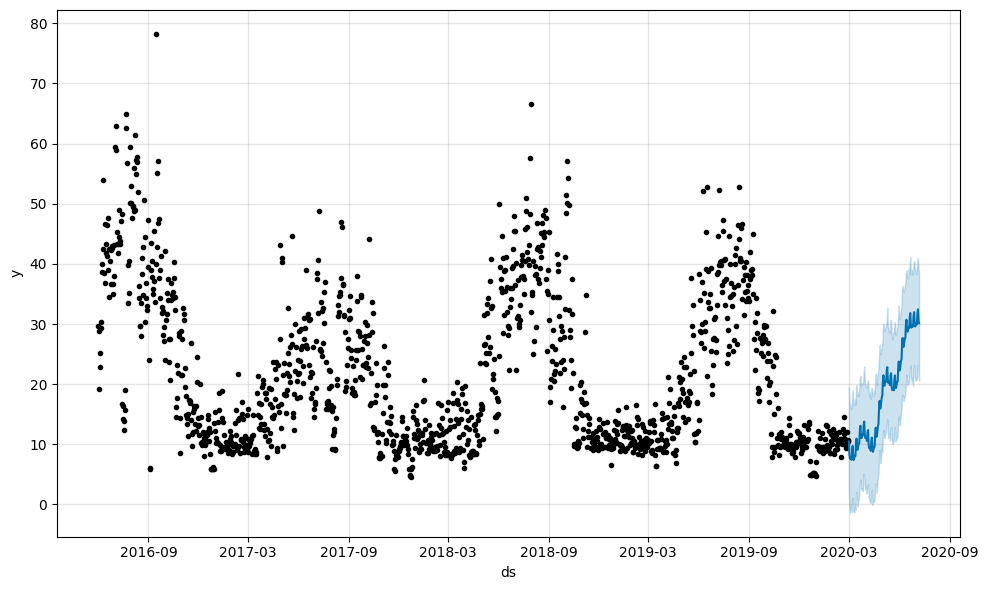

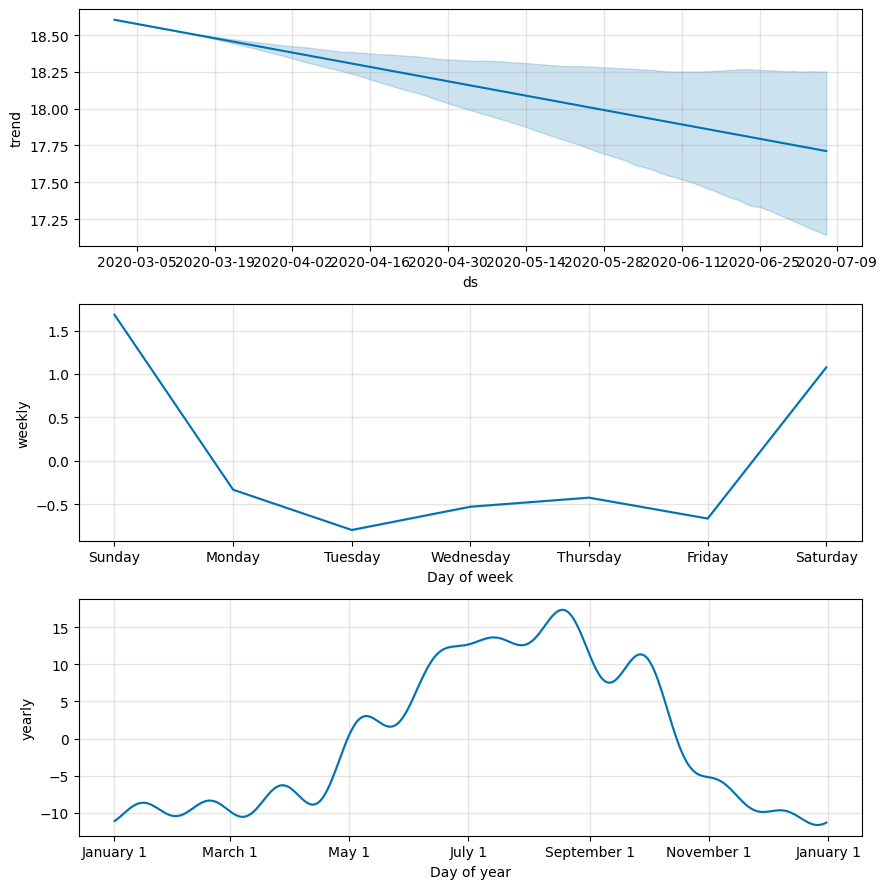

In [109]:
#3:
fig1 = model.plot(forecast)
fig2 = model.plot_components(forecast)

In [110]:
#4:

train_mae = mean_absolute_error(train['y'], model.predict(train[['ds']])['yhat'])
test_mae = mean_absolute_error(test['y'], test['yhat'])

print(f'MAE Entrenamiento: {train_mae}')
print(f'MAE Prueba: {test_mae}')

MAE Entrenamiento: 4.817481017717443
MAE Prueba: 4.921079315201517


In [111]:
#5:

test['error'] = test['y'] - test['yhat']

fig_error = px.line(test, x='ds', y='error', title='Error del Modelo Prophet')
fig_error.show()

Se puede observar una gran diferencia con respecto a los modelos anteriores, ya que oscilan mucho menos a lo largo del tiempo (Tambien debe considerarse que es menos tiempo en este testeo). En cuanto a la estacionalidad, se puede identificar que varia en algunas semanas mas que en otras, pero sobre todo en mayo y junio hay un alza en el error.

## 1.4 Incluyendo Regresores [5 puntos]

<center>
<img src ="https://i.redd.it/64hwjftunjjd1.gif" width = 400 />

Con los nuevos resultados obtenidos del modelo Prophet, usted le aconseja a Homero que puede mejorar sus predicciones al incluir regresores en el modelo, es decir, variables adicionales que pueden influir en la variable objetivo, en este caso, el consumo energético. Homero encuentra que es una buena idea y va en busca de ayuda donde el Profesor Frink, un destacado Científico de Springfield. Para suerte de Homero, Frink tenía un estudio reciente que registra las condiciones climáticas en Springfield, en el mismo intervalo de tiempo en que Homero disponía de los datos de consumo eléctrico. Con esta nueva información, usted le recomienda a Homero que podrían utilizar esta información meteorológica proporcionada como variables exógenas al modelo.

Sin embargo, al no comprender bien la importancia de los regresores, Homero decide confiar en sus capacidades y le pide que, por favor, incluya estas variables en el modelo para evaluar su impacto en las predicciones.

Para ello, usted debe:
0. Seleccionar las variables exógenas a utilizar del archivo `datos_frink.csv`. Añada estas variables a sus conjuntos de entrenamiento y prueba mediante `merge`. [0 puntos]
1. Cree el modelo Prophet e incluya los regresores (variables exógenas) al modelo. Luego realice el entrenamiento. **Hint**: Utilice el método `.add_regressor()`. Mas información en el siguiente [Enlace](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#additional-regressors). [2 puntos]
2. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
3. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. Analice sus resultados. [1 punto]
4. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y de prueba. ¿Hay un comportamiento estacional en la serie? ¿Influyen estas variables en el comportamiento del consumo energético en el hogar de Homero? [1 punto]

Los datos del dataset de Frink son los siguientes:

* **date**: Fecha de medición.
* **Temp_max**: Temperatura máxima registrada durante el día (en °F).
* **Temp_avg**: Temperatura promedio registrada durante el día (en °F).
* **Temp_min**: Temperatura mínima registrada durante el día (en °F).
* **Dew_max**: Punto de rocío máximo registrado durante el día (en °F).
* **Dew_avg**: Punto de rocío promedio registrado durante el día (en °F).
* **Dew_min**: Punto de rocío mínimo registrado durante el día (en °F).
* **Hum_max**: Humedad máxima registrada durante el día (en porcentaje).
* **Hum_avg**: Humedad promedio registrada durante el día (en porcentaje).
* **Hum_min**: Humedad mínima registrada durante el día (en porcentaje).
* **Wind_max**: Velocidad máxima del viento registrada durante el día (en millas por hora, mph).
* **Wind_avg**: Velocidad promedio del viento registrada durante el día (en millas por hora, mph).
* **Wind_min**: Velocidad mínima del viento registrada durante el día (en millas por hora, mph).
* **Press_max**: Presión atmosférica máxima registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_avg**: Presión atmosférica promedio registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_min**: Presión atmosférica mínima registrada durante el día (en pulgadas de mercurio, Hg).

**Respuesta:**

In [112]:
#0:

#data_frink = pd.read_csv(path + '/datos_frink.csv')
data_frink = pd.read_csv('./datos_frink.csv')
exog_vars = ['Temp_avg', 'Dew_avg', "Hum_avg", "Wind_avg", "Press_avg"]

data_frink['date'] = pd.to_datetime(data_frink['date'])
data_frink = data_frink.rename(columns={'date': 'ds'})

train = train.merge(data_frink[['ds'] + exog_vars], on='ds', how='left')
test = test.merge(data_frink[['ds'] + exog_vars], on='ds', how='left')

In [113]:
#1:

model2 = Prophet()

for var in exog_vars:
    model2.add_regressor(var)
model2.fit(train)

23:50:38 - cmdstanpy - INFO - Chain [1] start processing
23:50:38 - cmdstanpy - INFO - Chain [1] done processing


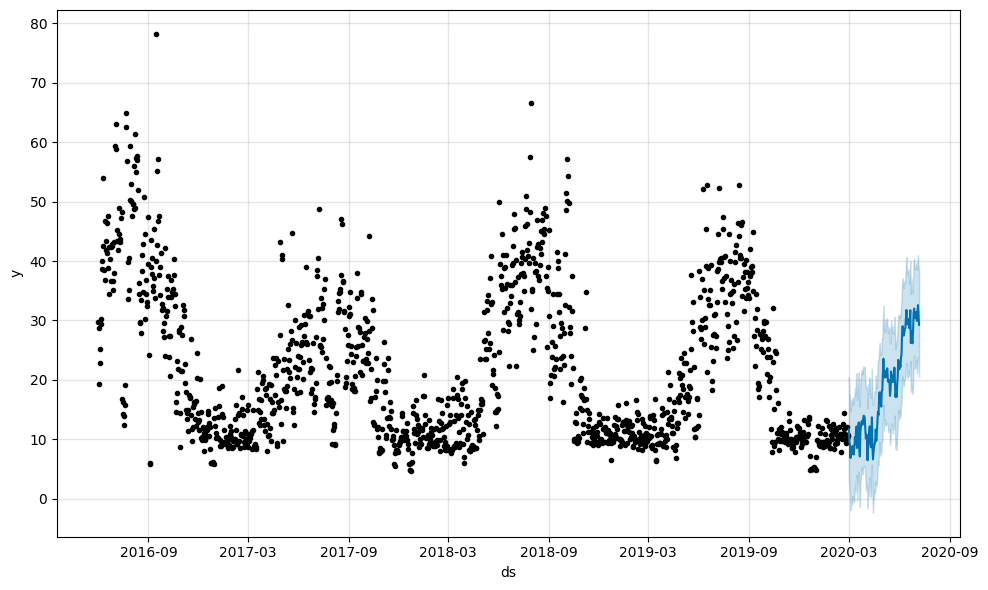

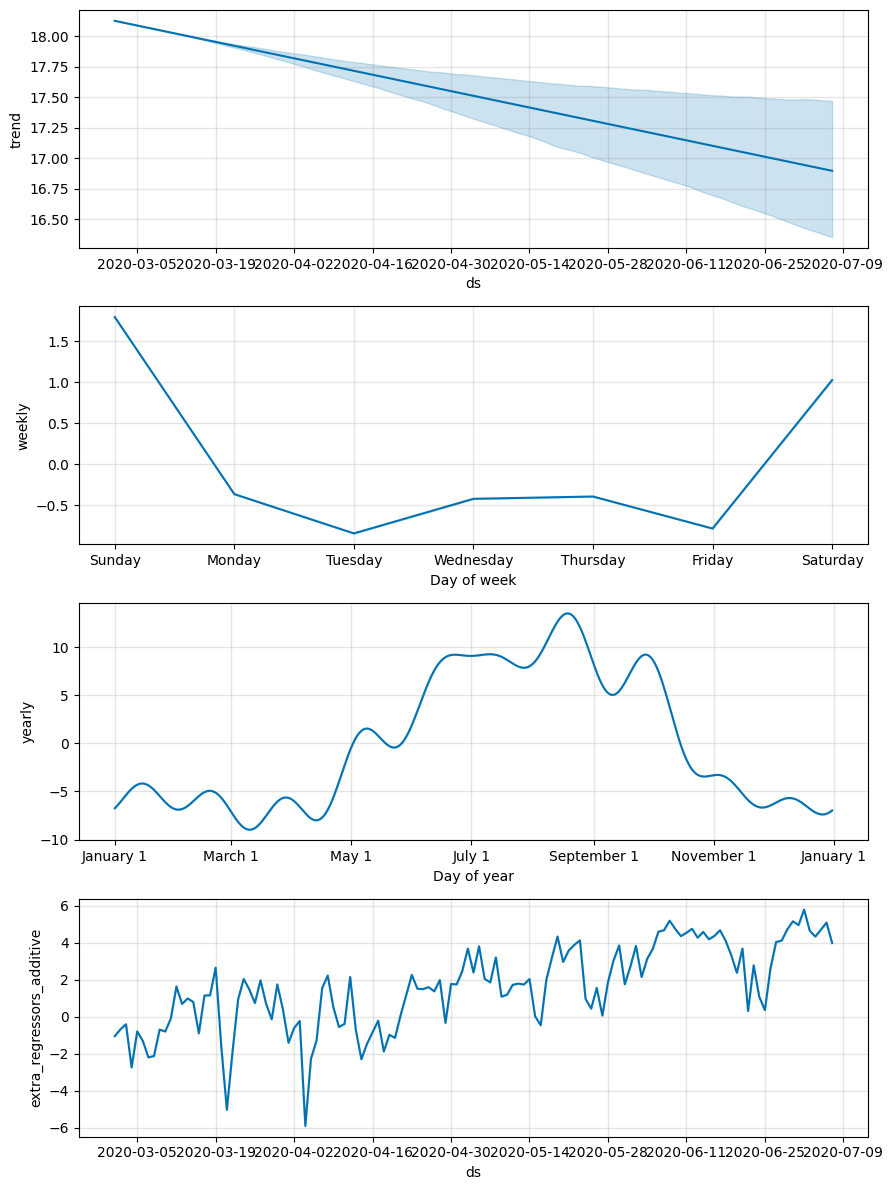

In [114]:
#2:

futuro2 = test[['ds'] + exog_vars]
forecast2 = model2.predict(futuro2)
fig3 = model2.plot(forecast2)
fig4 = model2.plot_components(forecast2)

In [115]:
#3:

train_predictions2 = model2.predict(train[['ds'] + exog_vars])['yhat']
train_mae2 = mean_absolute_error(train['y'], train_predictions2)

test['yhat2'] = forecast2['yhat']
test_mae2 = mean_absolute_error(test['y'], test['yhat2'])

print(f'MAE Entrenamiento: {train_mae2}')
print(f'MAE Prueba: {test_mae2}')

MAE Entrenamiento: 4.717026073148191
MAE Prueba: 4.513165640734094


Se puede ver que los MAE de los 2 conjuntos son menores con respectos a los demas modelos utilizados antes. Esto se debe a la implementacion de regresores como las variables externas de data_frink.

In [116]:
# Calcular el error (Valor real - Valor predicho)
test['error2'] = test['y'] - test['yhat2']

fig_error = px.line(test, x='ds', y='error2', title='Error del Modelo Prophet con Variables externas')
fig_error.show()

Los resultados son muy similares a los anteriores. Esto indica que las variables exogenas ayudan a explicar el consumo en el hogar de Homero, pero no de manera significativa.

## 1.5 Aplicando Lags [7 puntos]

<center>
<img src ="https://i.gifer.com/J45h.gif" width = 400 />

Homero, satisfecho con los resultados obtenidos, cree que aún puede mejorar el rendimiento del modelo incorporando lags de las variables exógenas. Se le ocurre que, al incluir estos lags, podría identificar cómo los valores pasados de las variables influyen en la evolución de la variable objetivo. Con esta idea en mente, Homero solicita su ayuda para encontrar y aplicar los lags adecuados a las variables exógenas de manera efectiva.

Para ello, a usted se le pide que:

1. Calcule la `Autocorrelación Parcial` de las variables exógenas `avg` que usted haya considerado. Por ejemplo: `Temp_avg, Dew_avg, etc`. Luego determine la cantidad de rezagos (lags) que se va a aplicar a cada una de las variables. Justifique. [1 punto]

2. Aplique los lags determinados en el paso anterior e incluyalos como variables en los conjuntos train y test. [1 punto]

3. Impute los valores nulos de los nuevos atributos lags mediante la media de cada variable. [1 punto]

4. Cree y entrene el modelo Prophet e incluya las variables exógenas y adicionalmente sus respectivos lags al modelo. [1 punto]

5. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
6. Calcule el `MAE` de la predicción en el conjunto de prueba y en el de entrenamiento. Analice sus resultados. [1 punto]
7. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y en el de prueba. ¿Hay un comportamiento estacional en la serie? ¿Como afecta la inclusión de los lags en el desempeño del modelo? [1 punto]


**Respuesta:**

<Figure size 1000x400 with 0 Axes>

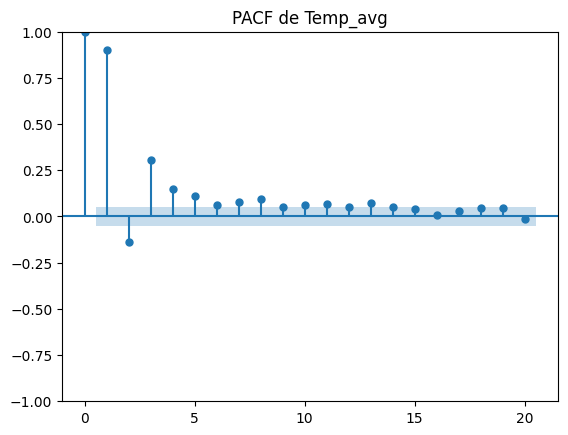

<Figure size 1000x400 with 0 Axes>

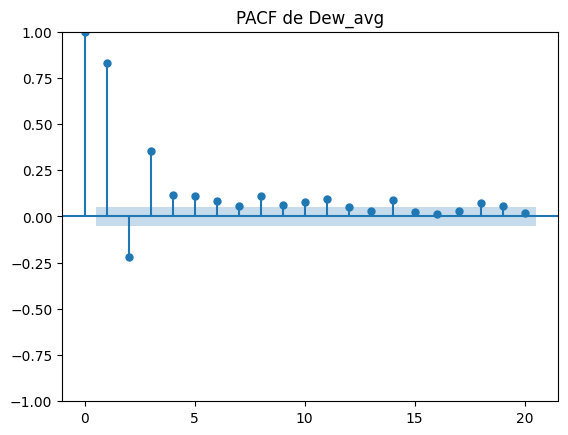

<Figure size 1000x400 with 0 Axes>

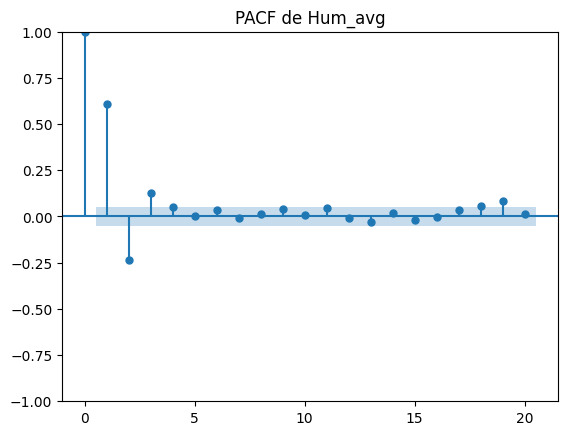

<Figure size 1000x400 with 0 Axes>

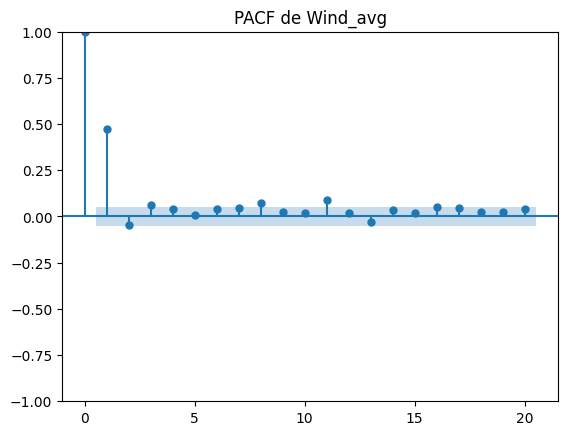

<Figure size 1000x400 with 0 Axes>

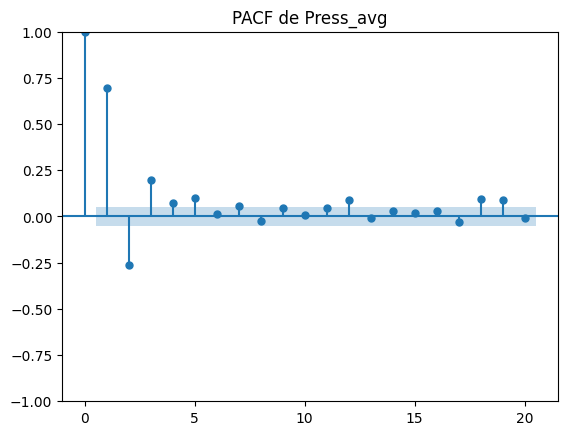

In [117]:
##1:
from statsmodels.graphics.tsaplots import plot_pacf

for var in exog_vars:
    plt.figure(figsize=(10, 4))
    plot_pacf(data_frink[var], lags=20, method='ywm')
    plt.title(f'PACF de {var}')
    plt.show()

Utilizaremos lags = 1 en cada una de las variables segun las figuras.

In [118]:
#2:

exog_vars_lagged = [f'{col}_lag1' for col in exog_vars]
for col in exog_vars:
    train[f'{col}_lag1'] = train[col].shift(1)
    test[f'{col}_lag1'] = test[col].shift(1)

In [119]:
#3:

train[exog_vars_lagged] = train[exog_vars_lagged].fillna(train[exog_vars_lagged].mean())
test[exog_vars_lagged] = test[exog_vars_lagged].fillna(test[exog_vars_lagged].mean())

In [120]:
#4:

model3 = Prophet()

for col in exog_vars_lagged:
    model3.add_regressor(col)

model3.fit(train)

futuro3 = test[['ds'] + exog_vars_lagged]
forecast3 = model3.predict(futuro3)

test['yhat3'] = forecast3['yhat']

23:50:44 - cmdstanpy - INFO - Chain [1] start processing
23:50:44 - cmdstanpy - INFO - Chain [1] done processing


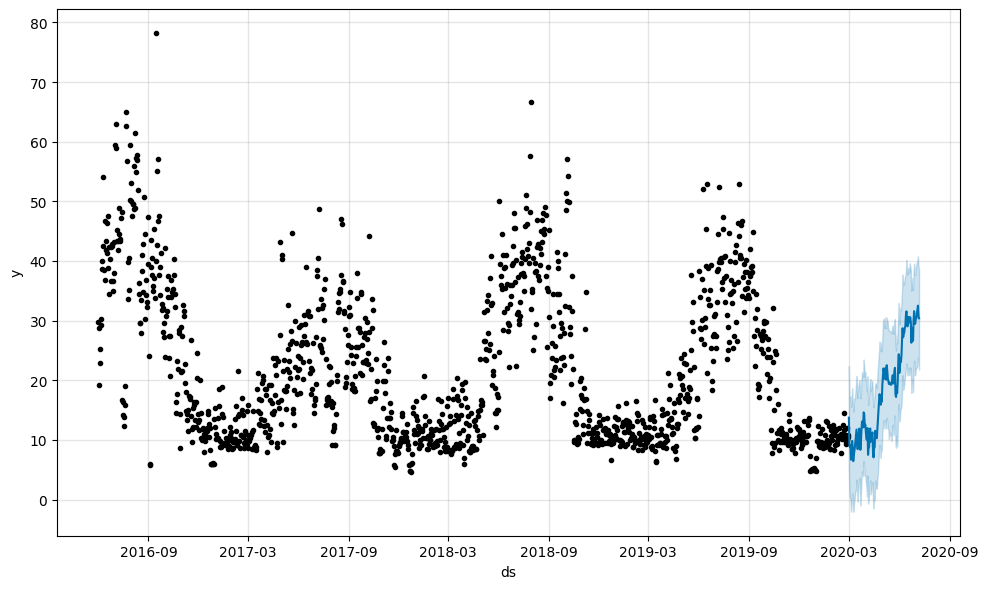

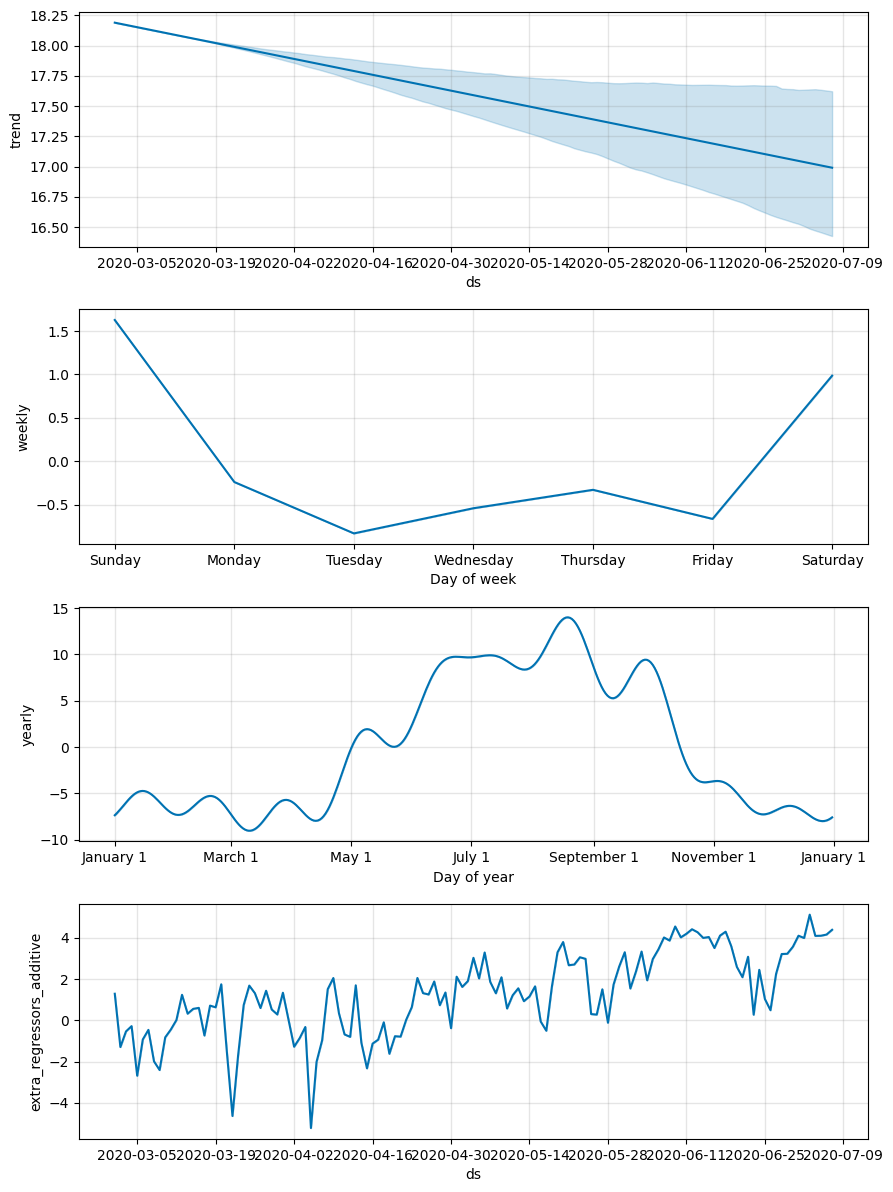

In [121]:
#5:

fig5 = model3.plot(forecast3)

fig6 = model3.plot_components(forecast3)

In [122]:
#6:

mae_test3 = mean_absolute_error(test['y'], test['yhat3'])
mae_train3 = mean_absolute_error(train['y'], model3.predict(train[['ds'] + exog_vars_lagged])['yhat'])

print(f'MAE en el conjunto de prueba: {mae_test3}')
print(f'MAE en el conjunto de entrenamiento: {mae_train3}')

MAE en el conjunto de prueba: 4.636191400135986
MAE en el conjunto de entrenamiento: 4.738348182841289


Los resultados son muy parecidos al modelo anterior, por lo que se puede decir que no ha habido un cambio drastico al incorporar lags. Tambien se puede ver que incluso los MAE aumentan levemente, por lo que su incorporacion no dio mejores resultados.

In [123]:
#7:

test['error3'] = test['y'] - test['yhat3']

fig_error = px.line(test, x='ds', y='error3', title='Error del Modelo Prophet usando Lags')
fig_error.show()

La incorporacion de lags, dado los resultados vistos, no han aportado significativamente en realizar forecast. Los errores son muy similares, practicamente iguales. Existen diferencias, como en la semana del 10 de mayo, que el error solo se toma en un punto, a diferencia que el modelo anterior, donde este se mantenia en el siguiente punto.

## 1.6 Optimizando Prophet [6 puntos]

<center>
<img src ="https://i.gifer.com/BKlg.gif" width = 500 />

Homero, contento con sus resultados, decide compartir su trabajo en LinkedIn. Sin embargo, justo antes de realizar la publicación, su hija Lisa Simpson le comenta que su modelo podría mejorar aún más mediante la optimización de hiperparámetros. Aunque Homero no entiende muy bien a qué se refiere Lisa, decide confiar en su conocimiento y le pide ayuda para implementar la optimización.

Lisa le prepara una función llamada optimize_prophet, que recibe como entrada el registro histórico, los datos a predecir (futuros), el nombre de las variables exógenas y una grilla de hiperparámetros que se desea modificar.

Después de varios intentos, Homero no logra utilizar la función de Lisa y, desesperado por publicar sus resultados en internet, se acerca a usted en busca de ayuda.

Para ello, usted decide realizar los siguientes pasos:

1. Crear una grilla donde se modifiquen los siguientes hiperparámetros: `changepoint_prior_scale`, `seasonality_prior_scale`, `seasonality_mode`, `changepoint_range` y encuentre los hiperparámetros que optimicen el `MAE`. `Nota:` Utilice la función `optimize_prophet()` dada en el enunciado. [1 punto]
2. Crear y entrenar un modelo Prophet utilizando los mejores parámetros encontrados, incluyendo regresores (variables exógenas). [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y en el de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en ambos conjuntos. Analice sus resultados. [1 punto]


In [124]:
#NO MODIFICAR ESTA CELDA

import itertools
import numpy as np
import pandas as pd
from tqdm import tqdm
import logging

# Silenciar el logging de Prophet
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)


def optimize_prophet(df, df_to_pred, features, param_grid ):
  '''
  Función que recibe como entrada:
  -df: data entrenamiento.
  -df_to_pred: data a predecir (test).
  -features: lista de variables exógenas.
  -param_grid: grilla de hiperparámetros.

  Retorna:
  -tuning_results: Dataframe con resultados de la optimización.
  -best_params: Diccionario de mejores parámetros encontrados.
  '''

  # Generate all combinations of parameters
  all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
  MAEs = []  # Store the MAEs for each params here

  # Use tqdm to add a progress bar to the parameter tuning loop
  for params in tqdm(all_params, desc="Tuning Prophet parameters"):
      m = Prophet(**params)  # Fit model with given params
      for feature in features:
          m.add_regressor(feature)
      m.fit(df)

      # Prepare future dataframe
      df_prop = m.make_future_dataframe(periods=len(df_to_pred))
      df_feat = pd.concat([df[features], df_to_pred[features]]).reset_index(drop=True)
      df_prop[features] = df_feat[features]

      # Make predictions
      forecast = m.predict(df_prop)
      forecast_pred = forecast[forecast['ds'].isin(df_to_pred['ds'])].reset_index(drop=True)

      # Calculate MAE for the predictions
      mae_pred = mean_absolute_error(df_to_pred['y'], forecast_pred['yhat'])
      MAEs.append(mae_pred)

  # Find the best parameters
  tuning_results = pd.DataFrame(all_params)
  tuning_results['MAEs'] = MAEs
  tuning_results = tuning_results.sort_values(by='MAEs', ascending=True)
  best_params = all_params[np.argmin(MAEs)]
  return tuning_results, best_params

**Respuesta:**

In [125]:
#1:

param_grid = {
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0],
    'seasonality_mode': ['additive', 'multiplicative'],
    'changepoint_range': [0.8, 0.9]
}

features = exog_vars
tuning_results, best_params = optimize_prophet(train, test, features, param_grid)

print("Mejores Hiperparámetros:", best_params)
print(tuning_results.head())

Tuning Prophet parameters: 100%|██████████| 36/36 [01:00<00:00,  1.68s/it]

Mejores Hiperparámetros: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.9}
    changepoint_prior_scale  seasonality_prior_scale seasonality_mode  \
7                      0.01                     0.10   multiplicative   
6                      0.01                     0.10   multiplicative   
10                     0.01                     1.00   multiplicative   
11                     0.01                     1.00   multiplicative   
1                      0.01                     0.01         additive   

    changepoint_range      MAEs  
7                 0.9  4.041443  
6                 0.8  4.060525  
10                0.8  4.061193  
11                0.9  4.072919  
1                 0.9  4.097444  


In [126]:
#2:

best_model = Prophet(**best_params)

for feature in features:
    best_model.add_regressor(feature)

best_model.fit(train)

best_future = best_model.make_future_dataframe(periods=len(test))
best_future[features] = pd.concat([train[features], test[features]]).reset_index(drop=True)

best_forecast = best_model.predict(best_future)

/tmp/ipykernel_305533/686926817.py:4: UserWarning:

Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.

/tmp/ipykernel_305533/686926817.py:7: UserWarning:

Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.



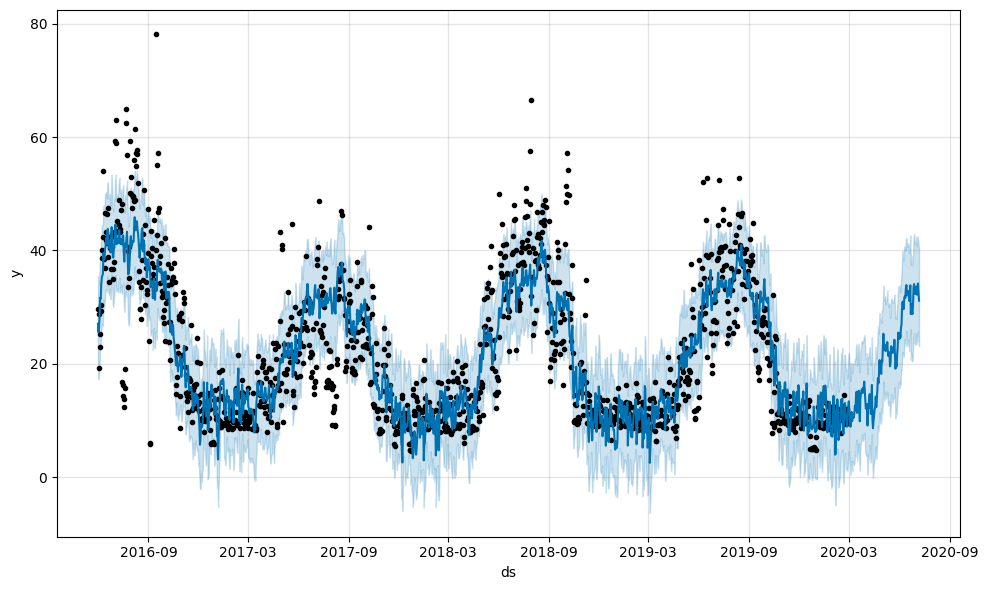

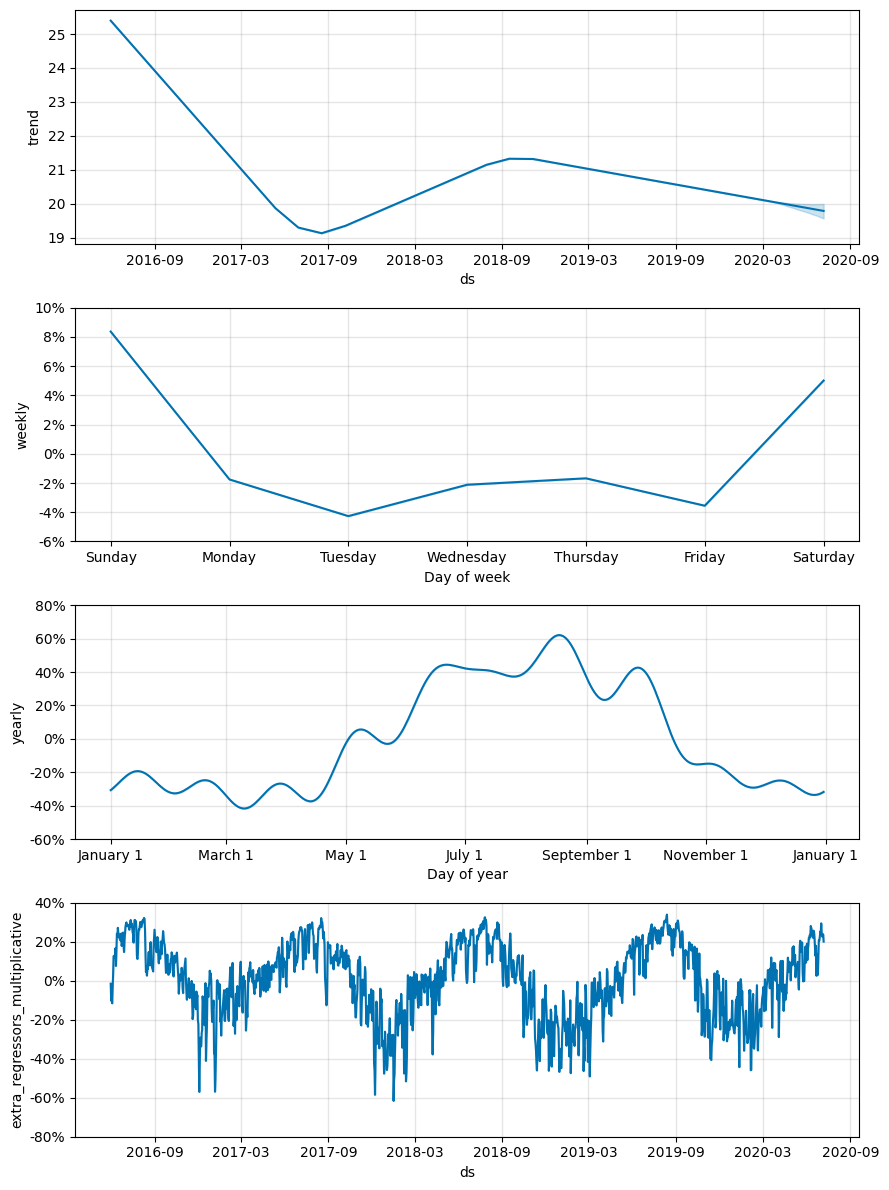

In [127]:
#3:

fig = best_model.plot(best_forecast)
fig.show()

fig_components = best_model.plot_components(best_forecast)
fig_components.show()

In [128]:
#4:

train_pred = best_forecast[best_forecast['ds'].isin(train['ds'])].reset_index(drop=True)
test_pred = best_forecast[best_forecast['ds'].isin(test['ds'])].reset_index(drop=True)

mae_train4 = mean_absolute_error(train['y'], train_pred['yhat'])
mae_test4 = mean_absolute_error(test['y'], test_pred['yhat'])

print(f'MAE en el conjunto de entrenamiento: {mae_train4}')
print(f'MAE en el conjunto de prueba: {mae_test4}')

MAE en el conjunto de entrenamiento: 4.863322355698139
MAE en el conjunto de prueba: 4.041442522812973


In [129]:
#5:

train['error4'] = train['y'] - train_pred['yhat']
test['error4'] = test['y'] - test_pred['yhat']

fig_train_error = px.line(train, x='ds', y='error4', title='Error en el Conjunto de Entrenamiento')
fig_train_error.show()

fig_test_error = px.line(test, x='ds', y='error4', title='Error en el Conjunto de Prueba')
fig_test_error.show()

# **2. Sistemas de Recomendación (30 puntos)**

## Homero contra la Prohibición

<center>
<img src ="https://i.ytimg.com/vi/rMSXXuhZjYY/maxresdefault.jpg" width = 500 />

En Springfield, el caos estalló cuando las autoridades prohibieron el alcohol. Pero como siempre, donde otros ven problemas, Homero Simpson ve oportunidades. Decidido a mantener las fiestas vivas, se convirtió en el Barón de la Cerveza en un abrir y cerrar de ojos. Con la ayuda de su buen amigo Moe el cantinero, Homero obtuvo un valioso dataset llamado `cervezas.csv`, que contiene valoraciones de los ciudadanos de Springfield sobre distintas cervezas. Homero quiere asegurarse de ofrecer las cervezas más apreciadas para mantener a su clientela oculta y feliz, mientras eludía la mirada del estricto Elio Pez. Por ende, Homero lo contacta para solicitar de su ayuda en esta nueva labor.

El dataset contiene los siguientes atributos:

  * userId: Identificador de los ciudadanos/usuarios
  * beerId: Identificador único de cada cerveza
  * rating: Evaluación otorgada por el ciudadano a la cerveza, en un rango de 1.0 a 5.0.
  * beerName: Nombre de la cerveza
  * beerStyle: Tipo de Cerveza.



In [ ]:
#!pip install surprise

In [48]:
# Librerias extras
from sklearn.preprocessing import LabelEncoder

from surprise import accuracy
from surprise.reader import Reader
from surprise.dataset import Dataset
from surprise.prediction_algorithms.knns import KNNBasic
from surprise.prediction_algorithms.matrix_factorization import SVD
from surprise.accuracy import mae
from surprise import NMF
from collections import defaultdict
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

import pandas as pd
from copy import deepcopy
import plotly.express as px


## Carga de los datos [0 puntos]

Cargue el dataset `cervezas.csv` y realice una breve exploración de los datos. ¿Hay valores nulos? ¿Cuantos cervezas se estan evaluando? ¿Cuantos ciudadanos participaron de esta evaluación?

In [45]:
#CODIGO AQUI
cervezas = pd.read_csv('./cervezas.csv')

# cervezas = pd.read_csv(path + "/cervezas.csv")

def eda(dataframe):
    pd.options.display.max_rows = 200
    pd.set_option('display.max_columns', None)

    print('1.- El DataFrame tiene', dataframe.shape[0],'filas y', dataframe.shape[1], 'columnas\n')
    print('2.- El DataFrame está compuesto por las siguientes columnas: ', list(dataframe.columns),'\n')
    print('3.- Ejemplos de filas del DataFrame:\n')
    print('Primeras 5 filas:')
    display(dataframe.head(5))
    print('Últimas 5 filas:')
    display(dataframe.tail(5))
    print('Muestreo aleatorio de 5 filas:')
    display(dataframe.sample(5))
    print('4.- Descripción numérica del Dataframe:\n')
    display(dataframe.describe())
    print('5.- Cantidad de valores nulos por columna:')
    display(dataframe.isna().sum())
    print('6.- Cantidad de valores únicos por columna:')
    unique_values = dataframe.nunique()
    display(unique_values)
    print('7.- Tipos de variables por columna:')
    display(dataframe.dtypes)
    print('8.- Filas duplicadas en el DataFrame:')
    display(dataframe.duplicated().sum())
    print('Desgloce variables con a lo más 6 categorías:')
    for column in dataframe.columns:
        if unique_values[column] <= 6:
            print(f'Columna: {column}')
            print(dataframe[column].value_counts())
            print('\n')

## 2.1 Caracterización Inicial [3 puntos]

Antes de entrenar nuestro sistema recomendador, es necesario caracterizar los datos disponibles y de esta manera tener un mejor entendimiento del problema a resolver. Para esto, se le pide lo siguiente:
1. Genere gráficos y/o estadística descriptiva con los datos. Utilice su análisis para responder las siguientes preguntas: [2 puntos]
  - ¿Cuantos *usuarios* hay en los datos?
  - ¿Cuantos *productos* hay en los datos?
  - ¿Cuantas *calificaciones* hay en los datos?
  - ¿Cuantas *calificaciones* faltantes hay en los datos?
  - ¿Cual es la media de las *calificaciones* entregadas por los usuarios? ¿Cómo cambia esto a través de los productos?  
2. Transforme los datos entregados a una matriz (usuario, producto) y muestre sus resultados. [1 punto]



In [46]:
cervezas = cervezas.drop_duplicates()
eda(cervezas)

1.- El DataFrame tiene 23493 filas y 5 columnas

2.- El DataFrame está compuesto por las siguientes columnas:  ['userId', 'beerId', 'rating', 'beerName', 'beerStyle'] 

3.- Ejemplos de filas del DataFrame:

Primeras 5 filas:


,userId,beerId,rating,beerName,beerStyle
0,144,995,3.0,Mai Bock,Maibock / Helles Bock
1,63,58695,4.0,Hop In The Dark Cascadian Dark Ale,American Black Ale
2,147,4083,5.0,Stone Ruination IPA,American Double / Imperial IPA
3,4261,40310,3.0,Noël Des Géants,Herbed / Spiced Beer
4,140,1904,5.0,Sierra Nevada Celebration Ale,American IPA


Últimas 5 filas:


,userId,beerId,rating,beerName,beerStyle
294784,418,32410,2.0,Left Hand Oktoberfest,Märzen / Oktoberfest
294819,1199,54827,2.5,Founders Black Biscuit,Old Ale
294913,140,1607,5.0,Sierra Nevada India Pale Ale,English India Pale Ale (IPA)
294988,435,20984,4.5,Barbary Coast Gold Rush,California Common / Steam Beer
295003,147,23495,3.0,Stone 05.05.05 Vertical Epic Ale,Belgian Strong Dark Ale


Muestreo aleatorio de 5 filas:


...

7.- Tipos de variables por columna:


userId         int64
beerId         int64
rating       float64
beerName      object
beerStyle     object
dtype: object

8.- Filas duplicadas en el DataFrame:


0

Desgloce variables con a lo más 6 categorías:


1. Hay 706 usuarios distintos
2. Hay 3747 productos distintos
3. Hay 23493 caliicaciones en los datos
4. No falta ninguna calificación
5. El promedio de las calificaciones de de 3.44. El promedio para las distintas cervezas se muestra a continuacion:

In [49]:
beer_avg_rating = cervezas.groupby('beerId')['rating'].mean().reset_index()

overall_avg_rating = cervezas['rating'].mean()

fig = px.line(beer_avg_rating, x='beerId', y='rating', title='Promedio de Rating por BeerId')

fig.add_hline(y=overall_avg_rating, line_dash="dash", line_color="red",
              annotation_text="Promedio General", annotation_position="top left")

fig.show()

In [50]:
#2:

cervezas_agg = cervezas.groupby(['userId', 'beerId'], as_index=False).agg({'rating': 'mean'})
user_product_matrix = cervezas_agg.pivot(index='userId', columns='beerId', values='rating')

## 2.2 Método Basado en Contenido [4 puntos]

<center>
<img src ="https://is1-ssl.mzstatic.com/image/thumb/WfNa_TwFpJoTWXQmU-BrbA/1200x675.jpg" width = 500 />

Como primera tarea, Homero le pide centrarse en las características de las cervezas y no en la interacción de los ciudadanos con esta. Adicionalmente, Homero esta buscando nuevas cervezas para su consumo personal, donde usted pudo notar que Homero esta identificado como `userId = 100` en el dataset. Por ende, Homero le pide las siguientes acciones:

1. Cree un dataframe que contenga las características de las cervezas, excluyendo las evaluaciones de los ciudadanos. `Nota:` No considere valores duplicados. [1 punto]
2. Implemente el método Bag of Words para procesar la columna `beerStyle`. Para ello, transforme las palabras a minúsculas, elimine stopwords en inglés y filtre las palabras que aparezcan en 10 documentos como mínimo. Guarde su resultado como un DataFrame. [1 punto].
> `Nota:` Le puede ser útil esta [documentacion](https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) y el método `.get_feature_names_out()`.
3. Cree una función que imprima las top 5 cervezas similares a `Chocolate Porter`, utilizando como medida de similitud la similitud coseno. [1 punto]
4. Identifique la cerveza mejor evaluada por Homero (`userId = 100`) y obtenga las top 5 cervezas similares a esa cerveza. [1 punto]

**Respuesta:**

In [51]:
from sklearn.feature_extraction.text import CountVectorizer

In [52]:
from sklearn.feature_extraction.text import CountVectorizer

#1:

beer_features = cervezas[['beerId', 'beerName', 'beerStyle']].drop_duplicates().reset_index()

#2:

stop_words = [
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours",
    "yourself", "yourselves", "he", "him", "his", "himself", "she", "her", "hers",
    "herself", "it", "its", "itself", "they", "them", "their", "theirs", "themselves",
    "what", "which", "who", "whom", "this", "that", "these", "those", "am", "is", "are",
    "was", "were", "be", "been", "being", "have", "has", "had", "having", "do", "does",
    "did", "doing", "a", "an", "the", "and", "but", "if", "or", "because", "as", "until",
    "while", "of", "at", "by", "for", "with", "about", "against", "between", "into",
    "through", "during", "before", "after", "above", "below", "to", "from", "up", "down",
    "in", "out", "on", "off", "over", "under", "again", "further", "then", "once",
    "here", "there", "when", "where", "why", "how", "all", "any", "both", "each", "few",
    "more", "most", "other", "some", "such", "no", "nor", "not", "only", "own", "same",
    "so", "than", "too", "very", "s", "t", "can", "will", "just", "don", "should", "now"
]

# Crear un vectorizador de texto
vectorizer = CountVectorizer(lowercase=True, stop_words=stop_words)

# Ajustar y transformar la columna beerStyle
X = vectorizer.fit_transform(beer_features['beerStyle'])

# Crear un DataFrame con las características
bag_of_words_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

In [53]:
#3
from sklearn.metrics.pairwise import cosine_similarity

def find_similar_beers(beer_name, beer_features, n=5):
    target_beer = beer_features[beer_features['beerName'] == beer_name]

    if target_beer.empty:
        print(f"No se encontró la cerveza '{beer_name}'")
        return

    target_index = target_beer.index[0]
    similarities = cosine_similarity(X[target_index], X).flatten()

    similar_indices = similarities.argsort()[-n-1:-1][::-1]
    similar_beers = beer_features.iloc[similar_indices]

    print(f"Top {n} cervezas similares a '{beer_name}':")
    print(similar_beers[['beerId', 'beerName']])

find_similar_beers('Chocolate Porter', beer_features)

Top 5 cervezas similares a 'Chocolate Porter':
      beerId                    beerName
729      262      Saint Bridget's Porter
2559   47747       Red Eye Coffee Porter
3176   57466        Cowboy Coffee Porter
3178   36341            State Pen Porter
1168   23269  Arctic Rhino Coffee Porter


In [54]:
#4
homero_ratings = cervezas[cervezas['userId'] == 100]
best_beer = homero_ratings.loc[homero_ratings['rating'].idxmax()]

print(f"La cerveza mejor evaluada por Homero es: {best_beer['beerName']}")

La cerveza mejor evaluada por Homero es: McNeill's Extra Special Bitter


In [55]:
print(beer_features[beer_features['beerName'] == "McNeill's Extra Special Bitter"])
find_similar_beers("McNeill's Extra Special Bitter", beer_features)

      index  beerId                        beerName  \
2770   8730    1393  McNeill's Extra Special Bitter   

                                beerStyle  
2770  Extra Special / Strong Bitter (ESB)  
Top 5 cervezas similares a 'McNeill's Extra Special Bitter':
      beerId                              beerName
3543    2077       S.O.B. (Special Old Bitter Ale)
3484   27599                   Phoenixx Double ESB
1864   34761  XS Imperial Younger's Special Bitter
384     1119                           Redhook ESB
1847    2017                          The Wise ESB


## 2.3 Filtros Colaborativos [16 puntos]

<center>
<img src ="https://i.makeagif.com/media/2-08-2016/McmGFQ.gif" width = 400 />

Después de consolidarse como el Barón de la Cerveza en Springfield, Homero Simpson decidió llevar su negocio clandestino a otro nivel. Al ser el único proveedor de alcohol en la ciudad, quiere asegurarse de que cada cerveza que elabora sea de la mejor calidad posible. Para lograrlo, planea usar las evaluaciones pasadas que los ciudadanos de Springfield han registrado sobre las distintas cervezas. Inspirado por los consejos de su amigo Moe, Homero se enteró de que puede implementar un sistema de recomendación basado en filtros colaborativos.

Ahora, Homero necesita de su ayuda para diseñar y elaborar distintos sistemas de filtros colaborativos que le permitan continuar con su reinado cervecero.

### 2.3.1 Filtros Colaborativos Basados en Memoria [8 puntos]

Para este tipo de filtros, Homero le pide lo siguiente:

1. Transforme el DataFrame de `pandas` a Dataset de `surprise`. `Hint`: Utilice solamente los identificadores de ciudadano, cerveza y rating. ¿Importa el orden? [1 punto]
2. Genere un conjunto de entrenamiento y uno de prueba, asegurando que el 30% de los datos sea destinado al conjunto de prueba. No olvide fijar una semilla para garantizar reproducibilidad. [1 punto]
3. Entrene un modelo de **KNN basado en usuarios** utilizando la `similitud coseno`. Luego realice predicciones en el conjunto de prueba. `Nota`: Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/knn_inspired.html) [2 puntos]
4. Calcule el MAE (Mean Absolute Error) de las predicciones realizadas por el modelo y muestre las predicciones en un DataFrame para su análisis. `Nota:` Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/accuracy.html#surprise.accuracy.mae) [2 puntos]
5. Repita los pasos 3 y 4 pero utilizando un modelo de **KNN basado en los productos**. [2 puntos]

**Respuesta:**

Sí, el orden de las columnas si imorta. Si se altera este orden, el sistema no podrá interpretar los datos de manera adecuada y esto puede generar errores al momento de crear el Dataset

In [56]:
df = cervezas

In [57]:

# Paso 1: Definir el Reader
reader = Reader(rating_scale=(1, 5))  # El rango de calificación de tus datos

# Paso 2: Cargar los datos en un Dataset de surprise
data = Dataset.load_from_df(df[['userId', 'beerId', 'rating']], reader)

# Paso 3: Crear conjuntos de entrenamiento y prueba
trainset, testset = train_test_split(data, test_size=0.3, random_state=42)

# Paso 4: Entrenar el modelo KNN basado en usuarios
# Utilizamos 'cosine' como medida de similitud
sim_options = {
    'name': 'cosine',
    'user_based': True  # True para KNN basado en usuarios
}

knn_model = KNNBasic(sim_options=sim_options)
knn_model.fit(trainset)

# Paso 5: Realizar predicciones en el conjunto de prueba
predictions = knn_model.test(testset)

# Paso 6: Mostrar algunas predicciones
for uid, iid, true_r, est, _ in predictions[:10]:  # Muestra las primeras 10 predicciones
    print(f'Usuario: {uid}, Cerveza: {iid}, Valor real: {true_r}, Predicción: {est:.2f}')

Computing the cosine similarity matrix...
Done computing similarity matrix.
Usuario: 147, Cerveza: 25353, Valor real: 4.5, Predicción: 3.83
Usuario: 141, Cerveza: 35653, Valor real: 5.0, Predicción: 3.50
Usuario: 188, Cerveza: 602, Valor real: 3.0, Predicción: 3.60
Usuario: 620, Cerveza: 1661, Valor real: 4.0, Predicción: 3.25
Usuario: 3818, Cerveza: 43687, Valor real: 1.5, Predicción: 3.25
Usuario: 1628, Cerveza: 10301, Valor real: 4.0, Predicción: 4.33
Usuario: 2391, Cerveza: 42193, Valor real: 4.5, Predicción: 4.00
Usuario: 5411, Cerveza: 35398, Valor real: 3.0, Predicción: 3.90
Usuario: 14879, Cerveza: 33624, Valor real: 2.5, Predicción: 3.38
Usuario: 828, Cerveza: 25277, Valor real: 3.0, Predicción: 3.83


In [58]:
import pandas as pd
from surprise import Dataset, Reader
from surprise.model_selection import train_test_split
from surprise import KNNBasic
from surprise import accuracy

In [59]:

# Paso 1: Transformar el DataFrame de pandas a Dataset de surprise
# Definimos el formato de los datos
reader = Reader(rating_scale=(1, 5))  # Asegúrate de que el rango de calificación sea el correcto
data = Dataset.load_from_df(df[['userId', 'beerId', 'rating']], reader)

# Paso 2: Crear conjuntos de entrenamiento y prueba
trainset, testset = train_test_split(data, test_size=0.3, random_state=42)

# Función para entrenar el modelo KNN y calcular el MAE
def train_knn_and_evaluate(trainset, testset, user_based=True):
    # Configuración del modelo KNN
    sim_options = {
        'name': 'cosine',
        'user_based': user_based  # True para KNN basado en usuarios, False para productos
    }
    
    # Entrenar el modelo
    knn_model = KNNBasic(sim_options=sim_options)
    knn_model.fit(trainset)

    # Realizar predicciones en el conjunto de prueba
    predictions = knn_model.test(testset)
    
    # Calcular el MAE
    mae = accuracy.mae(predictions, verbose=True)
    
    # Convertir las predicciones a un DataFrame para análisis
    pred_df = pd.DataFrame(predictions, columns=['userId', 'beerId', 'true_rating', 'predicted_rating', 'details'])
    return pred_df, mae

# Paso 3: Entrenar un modelo KNN basado en usuarios
user_based_predictions, user_based_mae = train_knn_and_evaluate(trainset, testset, user_based=True)
print("\nMAE para KNN basado en usuarios:", user_based_mae)
user_based_predictions.head()

# Paso 5: Entrenar un modelo KNN basado en productos
product_based_predictions, product_based_mae = train_knn_and_evaluate(trainset, testset, user_based=False)
print("\nMAE para KNN basado en productos:", product_based_mae)
product_based_predictions.head()


Computing the cosine similarity matrix...
Done computing similarity matrix.
MAE:  1.0378

MAE para KNN basado en usuarios: 1.0377587267599235
Computing the cosine similarity matrix...
Done computing similarity matrix.
MAE:  0.9122

MAE para KNN basado en productos: 0.9122399005622537


,userId,beerId,true_rating,predicted_rating,details
0,147,25353,4.5,3.814201,"{'actual_k': 40, 'was_impossible': False}"
1,141,35653,5.0,3.848602,"{'actual_k': 40, 'was_impossible': False}"
2,188,602,3.0,3.678272,"{'actual_k': 11, 'was_impossible': False}"
3,620,1661,4.0,3.760625,"{'actual_k': 15, 'was_impossible': False}"
4,3818,43687,1.5,3.707719,"{'actual_k': 40, 'was_impossible': False}"


### 2.3.2 Filtros Colaborativos Basados en Modelo [8 puntos]

Ahora Homero le pide que cambie el enfoque del tipo de filtro colaborativo a uno basado en modelo. Por ende, Homero le pide lo siguiente:

1. Entrene un modelo `NMF` , asegurándose de fijar la semilla para reproducibilidad. Luego genere predicciones para el conjunto de prueba. [2 puntos]
2. Calcule el MAE de las predicciones obtenidas y muestre los resultados de las predicciones en un DataFrame para su analisis. [1 punto]
3. Entrene un modelo `SVD` sobre el conjunto de entrenamiento. Posteriormente, genere las predicciones para el conjunto de prueba. [2 puntos]
4. Calcule el MAE de las predicciones y muestre los resultados de las predicciones en un DataFrame. [1 punto]
5. Compare los resultados de ambos modelos y seleccione el mejor a su criterio. Justifique. [2 puntos]

**Respuesta**

In [60]:
#CODIGO AQUI

# Función para entrenar un modelo y calcular el MAE
def train_model_and_evaluate(model_class, trainset, testset):
    # Entrenar el modelo
    model = model_class()
    model.fit(trainset)

    # Realizar predicciones en el conjunto de prueba
    predictions = model.test(testset)

    # Calcular el MAE
    mae = accuracy.mae(predictions, verbose=True)

    # Convertir las predicciones a un DataFrame para análisis
    pred_df = pd.DataFrame(predictions, columns=['userId', 'beerId', 'true_rating', 'predicted_rating', 'details'])
    return pred_df, mae


In [61]:
# Entrenar un modelo NMF
nmf_predictions, nmf_mae = train_model_and_evaluate(NMF, trainset, testset)
print("\nMAE para el modelo NMF:", nmf_mae)
nmf_predictions.head()


MAE:  1.0368

MAE para el modelo NMF: 1.0368470645063523


,userId,beerId,true_rating,predicted_rating,details
0,147,25353,4.5,3.727539,{'was_impossible': False}
1,141,35653,5.0,3.472297,{'was_impossible': False}
2,188,602,3.0,3.645863,{'was_impossible': False}
3,620,1661,4.0,3.310170,{'was_impossible': False}
4,3818,43687,1.5,3.278270,{'was_impossible': False}


In [62]:

# Entrenar un modelo SVD
svd_predictions, svd_mae = train_model_and_evaluate(SVD, trainset, testset)
print("\nMAE para el modelo SVD:", svd_mae)
svd_predictions.head()

MAE:  0.9659

MAE para el modelo SVD: 0.965855807694257


,userId,beerId,true_rating,predicted_rating,details
0,147,25353,4.5,3.638280,{'was_impossible': False}
1,141,35653,5.0,3.480455,{'was_impossible': False}
2,188,602,3.0,3.583452,{'was_impossible': False}
3,620,1661,4.0,3.416946,{'was_impossible': False}
4,3818,43687,1.5,3.260694,{'was_impossible': False}


En base a los resultados obtenidos, seleccionaría el modelo SVD como el mejor enfoque para este conjunto de datos. Su menor MAE indica que realiza predicciones más precisas en comparación con el modelo NMF

## 2.4 El Mejor Filtro Colaborativo [7 puntos]

Homero Simpson desea perfeccionar y extender su sistema de recomendaciones para cervezas en Springfield. En esta fase, busca implementar técnicas que le permitan no solo predecir las preferencias de los ciudadanos, sino también evaluar métricas que midan la eficacia de sus recomendaciones. Con el objetivo de recomendar las mejores K cervezas para usuarios específicos, Homero buscará comprender mejor cómo optimizar su sistema y satisfacer a sus clientes.

Para ello, usted ayudará a Homero realizando las siguientes labores:

1. Implemente la función `get_top_n()` que le permita extraer las `N` mejores cervezas recomendadas para cada ciudadano utilizando las predicciones generadas por el mejor modelo seleccionado en la sección anterior. Luego obtenga las `3` mejores cervezas recomendadas para Homero (`userId = 100`). `Hint`: Para cada ciudadano, elimine las predicciones duplicadas. [2 puntos]
2. Realice predicciones de rating para 5 cervezas aleatorias no evaluadas por Homero, para estimar las calificaciones que Homero podría darles. [1 punto]
3. Calcule los promedios de `precisión@k` y el `recall@k` para `k=10` y `threshold = 3.5`. Analice sus resultados. ¿Es un buen modelo? `Hint:` Utilice la función dada `precision_recall_at_k(...)`. [1 punto]
4. Calcule la `precisión@k` y el `recall@k` para valores de `k` que varíen entre 3 y 25 con paso de 1 unidad. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `k`. [1 punto]
5. Calcule la `precisión@k` y el `recall@k` para valores de `threshold` que varíen entre 3.0 y 4.5, con paso de 0.1. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `threshold`. [1 punto]
6. Finalmente utilice el mejor modelo para estimar los ratings faltantes. Muestre sus resultados en una matriz (usuario, producto) sin valores nulos. [1 punto]



In [63]:
#NO MODIFICAR ESTA CELDA
def precision_recall_at_k(predictions, k=10, threshold=3.5):

    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in user_ratings[:k]
        )
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
    return precisions, recalls

**Respuesta:**

In [64]:
#CODIGO AQUI


# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por el foro de U-cursos o por correo.

<center>
<img src ="https://i.gifer.com/origin/cb/cbd80e6045652ab123caffef72f29210_w200.gif" width = 400 />
